<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/03_Stationarity_and_Autocorrelation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3 실습: 정상성, 자기상관, 그리고 백색잡음
**Notebook:** `03_Stationarity_and_Autocorrelation.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 백색잡음(White Noise)과 랜덤워크(Random Walk)를 직접 생성하고 비교합니다.
2. 정상성(Stationarity)의 직관을 그래프와 통계량으로 확인합니다.
3. 자기상관함수(ACF)와 편자기상관함수(PACF)를 시각적으로 해석합니다.
4. ADF 검정과 KPSS 검정을 이용해 정상성을 점검합니다.
5. 비정상 시계열을 차분(Differencing)하여 더 안정적인 형태로 바꾸는 과정을 실습합니다.
6. 실제 금융 데이터의 가격 수준(Level)과 수익률(Return)을 비교하여 왜 차분이 필요한지 이해합니다.

---

## 왜 이 실습이 중요한가?
시계열 분석에서 정상성은 출발점에 해당합니다.  
ARIMA와 같은 전통 모형은 물론이고, 예측과 인과추론의 많은 절차는 데이터가 최소한 어느 정도 안정적인 구조를 갖는다는 전제 위에서 해석됩니다.

하지만 현실 데이터는 종종 평균이 이동하고, 추세를 가지며, 충격을 오래 끌고 갑니다.  
따라서 이 실습의 핵심은 단순히 검정 통계량을 외우는 것이 아니라, **정상 시계열과 비정상 시계열이 어떻게 다르게 보이는지**를 직접 체감하는 데 있습니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================
# pandas: 데이터 처리
# numpy: 수치 계산
# matplotlib: 시각화
# warnings: 불필요한 경고 메시지 제어
# statsmodels: ACF/PACF, ADF, KPSS 등 시계열 분석 도구
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 온라인 환경 준비
이번 실습은 Google Colab 또는 Jupyter Notebook에서 바로 실행할 수 있도록 구성했습니다.

실제 금융 시계열 예시를 위해 `yfinance`를 사용합니다.  
설치되어 있지 않다면 자동으로 설치합니다.


In [2]:
# ============================================
# 2. yfinance 설치 및 임포트
# ============================================

try:
    import yfinance as yf
    print("yfinance가 이미 설치되어 있습니다.")
except ImportError:
    print("yfinance가 설치되어 있지 않아 지금 설치합니다...")
    !pip -q install yfinance
    import yfinance as yf
    print("yfinance 설치가 완료되었습니다.")


yfinance가 이미 설치되어 있습니다.


## 2. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [3]:
# ============================================
# 3. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 3. 시뮬레이션 데이터 만들기: 백색잡음과 랜덤워크
정상성과 비정상성을 가장 직관적으로 이해하는 방법은 직접 데이터를 만드는 것입니다.

여기서는 두 가지 과정을 생성합니다.

1. **백색잡음 (White Noise)**  
   - 평균이 0
   - 분산이 일정
   - 과거가 미래에 정보를 주지 않음

2. **랜덤워크 (Random Walk)**  
   - 현재값이 직전값과 충격의 합으로 결정됨
   - 충격이 누적되므로 비정상성을 보이는 대표적 과정


In [4]:
# ============================================
# 4. 백색잡음과 랜덤워크 생성
# ============================================
# random seed를 고정하여, 누구나 같은 결과를 재현할 수 있도록 합니다.
# ============================================

np.random.seed(42)

n = 500

# 백색잡음: 평균 0, 표준편차 1의 정규분포에서 독립적으로 생성
white_noise = np.random.normal(loc=0, scale=1, size=n)

# 랜덤워크: 백색잡음을 누적합(cumsum)하여 생성
random_walk = np.cumsum(np.random.normal(loc=0, scale=1, size=n))

# 편의를 위해 pandas Series로 변환
wn_series = pd.Series(white_noise, name="White_Noise")
rw_series = pd.Series(random_walk, name="Random_Walk")

display(pd.DataFrame({
    "White_Noise": wn_series.head(10),
    "Random_Walk": rw_series.head(10)
}))


,White_Noise,Random_Walk
0,0.496714,0.926178
1,-0.138264,2.835594
2,0.647689,1.437027
3,1.523030,1.999996
4,-0.234153,1.349353
5,-0.234137,0.862228
6,1.579213,0.269834
7,0.767435,-0.594157
8,-0.469474,-0.545635
9,0.542560,-1.376585


## 4. 백색잡음과 랜덤워크의 시각적 비교
두 시계열을 같은 방식으로 그려보면 차이가 선명하게 드러납니다.

관찰 포인트는 다음과 같습니다.

- 백색잡음은 0 근처에서 위아래로 흔들리는가?
- 랜덤워크는 특정 방향으로 계속 떠다니는가?
- 충격이 누적되는 듯한 모습이 보이는가?


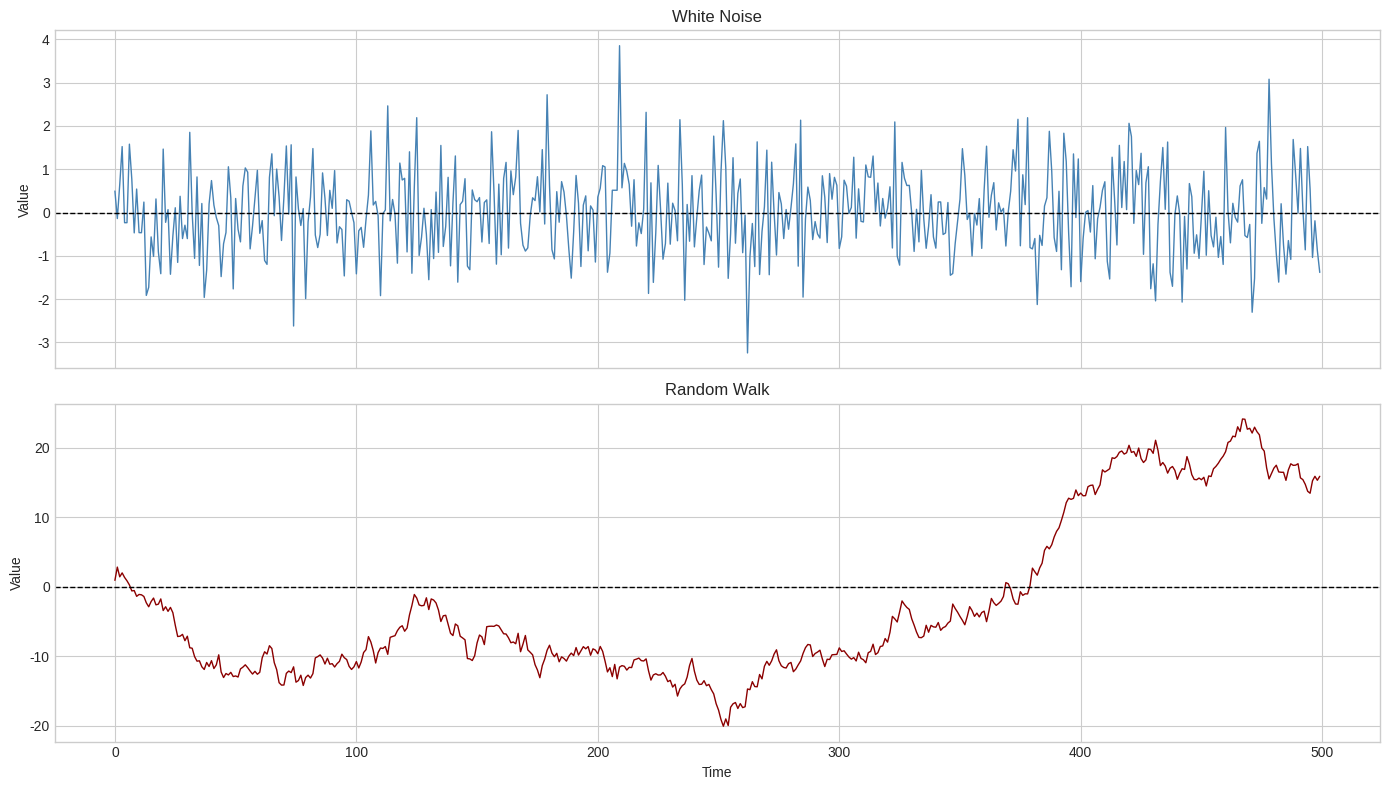

In [5]:
# ============================================
# 5. 백색잡음과 랜덤워크 플롯
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(wn_series, color="steelblue", linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("White Noise")
axes[0].set_ylabel("Value")

axes[1].plot(rw_series, color="darkred", linewidth=1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Random Walk")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()


## 5. 이동 평균과 이동 표준편차로 직관 점검
정상 시계열은 대체로 평균과 분산이 시간에 따라 크게 바뀌지 않습니다.  
따라서 롤링 평균과 롤링 표준편차를 그려 보면 정상성과 비정상성의 차이를 더 분명하게 볼 수 있습니다.


In [6]:
# ============================================
# 6. 롤링 통계량 계산
# ============================================

window = 30

wn_roll_mean = wn_series.rolling(window=window).mean()
wn_roll_std = wn_series.rolling(window=window).std()

rw_roll_mean = rw_series.rolling(window=window).mean()
rw_roll_std = rw_series.rolling(window=window).std()


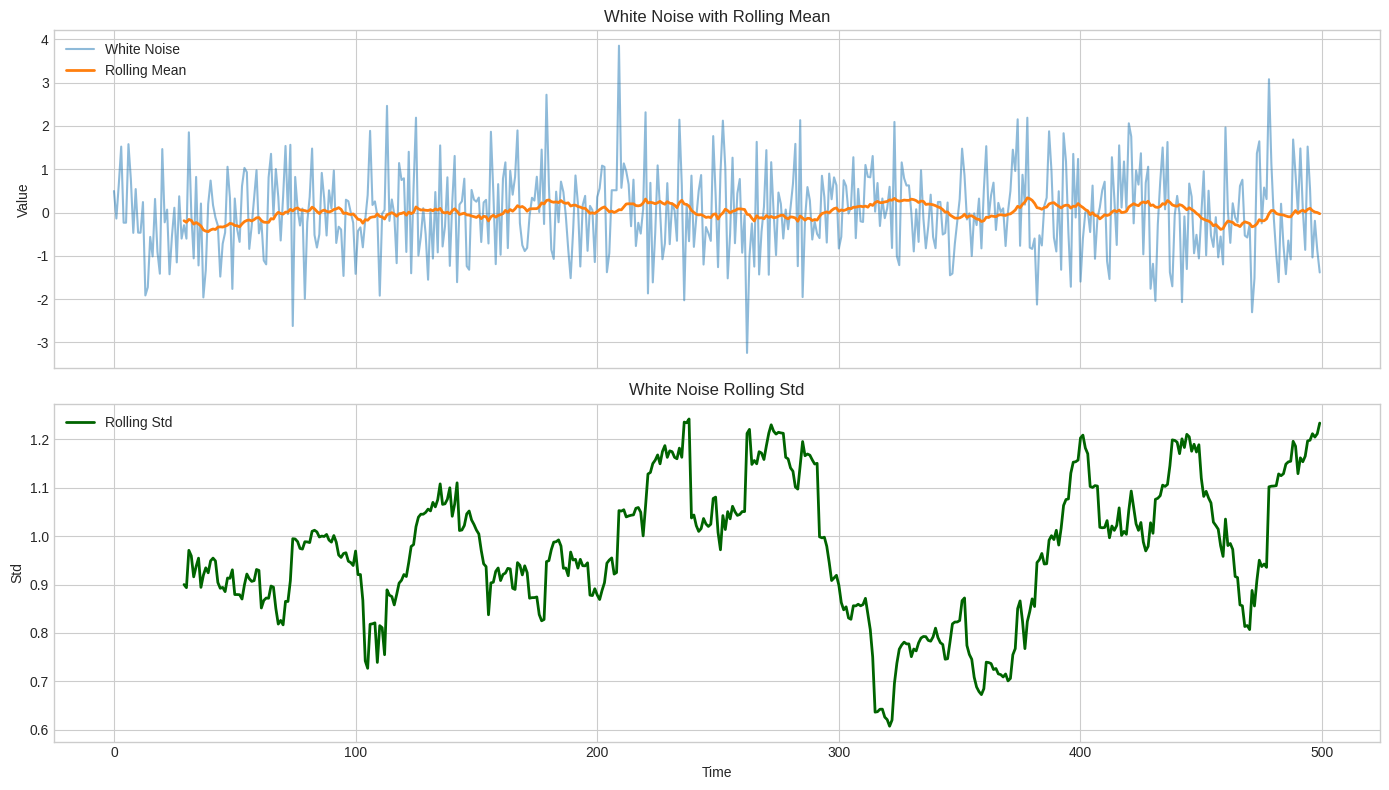

In [7]:
# ============================================
# 7. 백색잡음의 롤링 통계량
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(wn_series, label="White Noise", alpha=0.5)
axes[0].plot(wn_roll_mean, label="Rolling Mean", linewidth=2)
axes[0].set_title("White Noise with Rolling Mean")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(wn_roll_std, color="darkgreen", label="Rolling Std", linewidth=2)
axes[1].set_title("White Noise Rolling Std")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Std")
axes[1].legend()

plt.tight_layout()
plt.show()


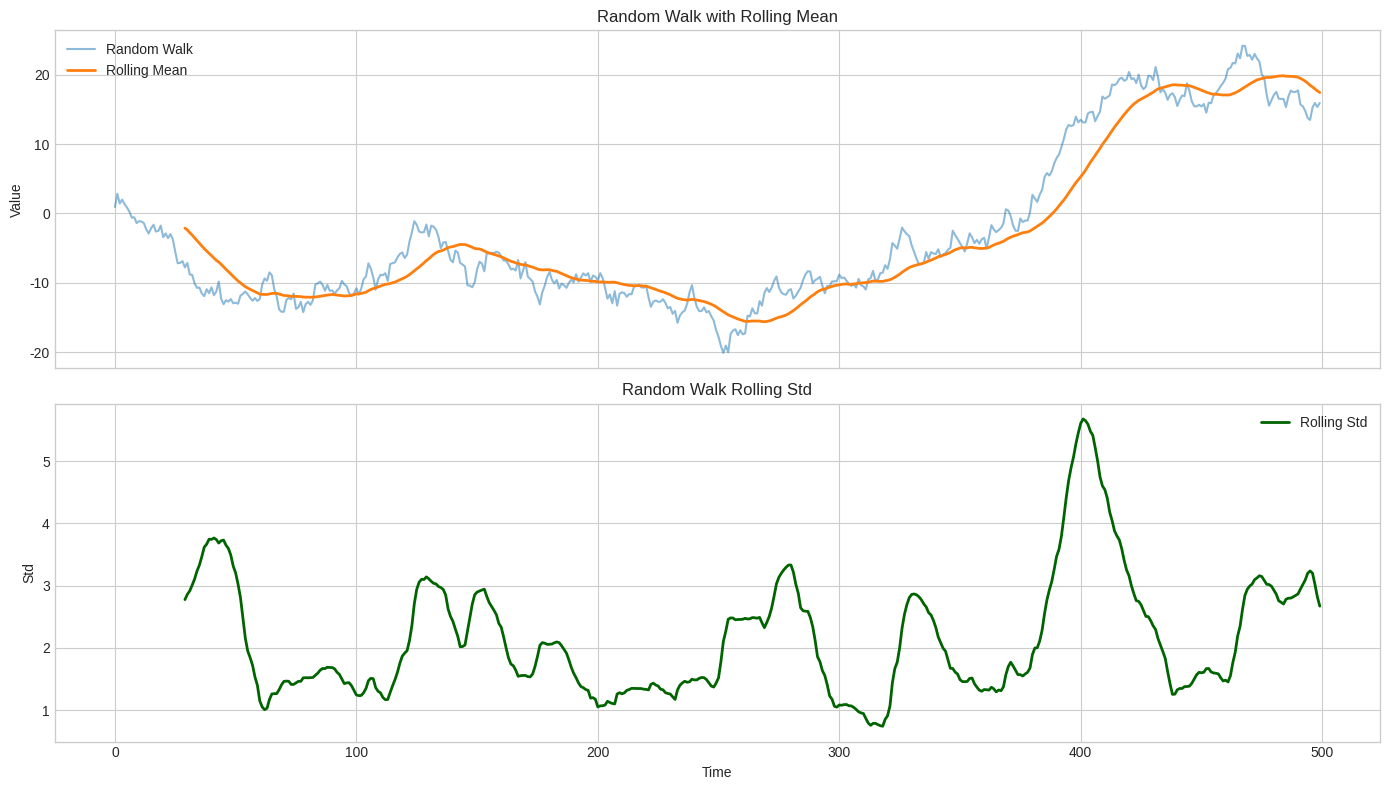

In [8]:
# ============================================
# 8. 랜덤워크의 롤링 통계량
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(rw_series, label="Random Walk", alpha=0.5)
axes[0].plot(rw_roll_mean, label="Rolling Mean", linewidth=2)
axes[0].set_title("Random Walk with Rolling Mean")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(rw_roll_std, color="darkgreen", label="Rolling Std", linewidth=2)
axes[1].set_title("Random Walk Rolling Std")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Std")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. ACF와 PACF 보기
시계열이 과거를 얼마나 기억하는지 보기 위해 ACF와 PACF를 사용합니다.

- **ACF (Autocorrelation Function)**: 여러 시차(lag)에 대한 자기상관
- **PACF (Partial Autocorrelation Function)**: 중간 시차의 효과를 제거한 직접 상관

정상성 진단에서 중요한 직관은 다음과 같습니다.

- 백색잡음은 ACF가 거의 0 근처에 머문다.
- 랜덤워크는 ACF가 매우 천천히 감소한다.


In [9]:
# ============================================
# 9. ACF/PACF 관련 함수 불러오기
# ============================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


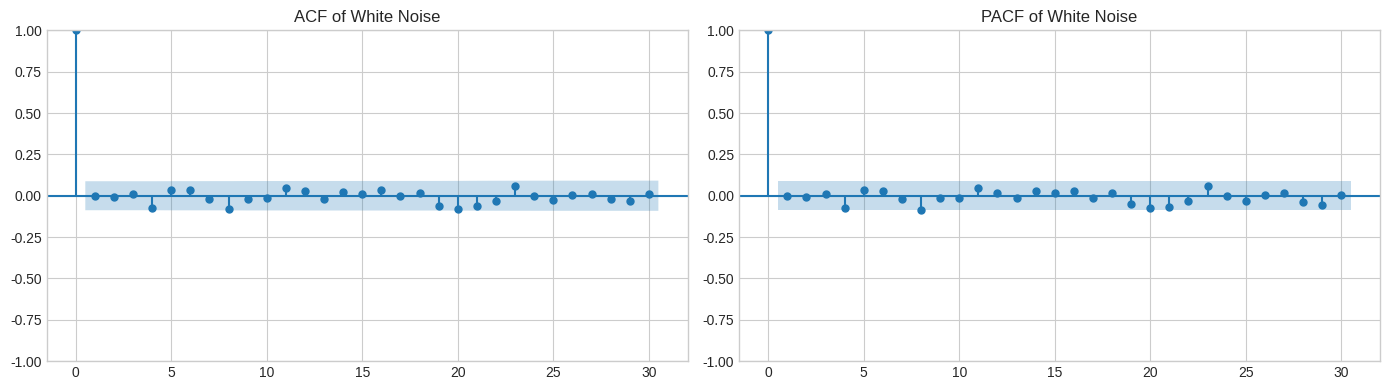

In [10]:
# ============================================
# 10. 백색잡음의 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(wn_series, lags=30, ax=axes[0])
plot_pacf(wn_series, lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of White Noise")
axes[1].set_title("PACF of White Noise")

plt.tight_layout()
plt.show()


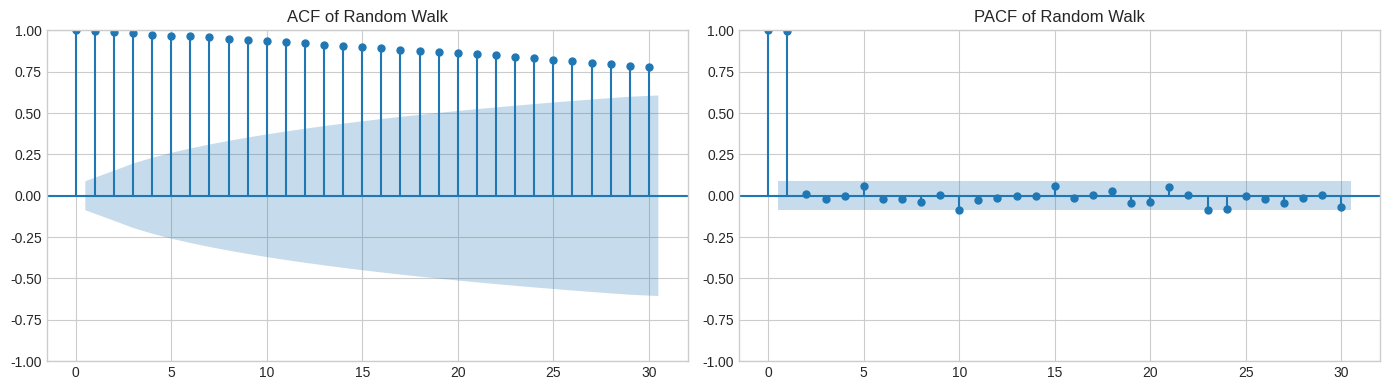

In [11]:
# ============================================
# 11. 랜덤워크의 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(rw_series, lags=30, ax=axes[0])
plot_pacf(rw_series, lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of Random Walk")
axes[1].set_title("PACF of Random Walk")

plt.tight_layout()
plt.show()


## 7. 정상성 검정: ADF와 KPSS
이제 그래프에서 본 직관을 통계 검정으로 확인해 보겠습니다.

### ADF 검정
- 귀무가설: 단위근이 존재한다 (비정상)
- p-value가 작으면 귀무가설을 기각 → 정상성 쪽에 가까움

### KPSS 검정
- 귀무가설: 정상 시계열이다
- p-value가 작으면 귀무가설을 기각 → 비정상 가능성


In [12]:
# ============================================
# 12. ADF와 KPSS 함수 불러오기
# ============================================

from statsmodels.tsa.stattools import adfuller, kpss


In [13]:
# ============================================
# 13. ADF / KPSS 결과를 보기 좋게 정리하는 함수
# ============================================

def stationarity_report(series, name="Series"):
    series = pd.Series(series).dropna()

    print(f"===== {name} =====")

    # ADF
    adf_result = adfuller(series, autolag="AIC")
    print("ADF Statistic :", round(adf_result[0], 4))
    print("ADF p-value   :", round(adf_result[1], 4))

    # KPSS
    kpss_result = kpss(series, regression="c", nlags="auto")
    print("KPSS Statistic:", round(kpss_result[0], 4))
    print("KPSS p-value  :", round(kpss_result[1], 4))
    print("-" * 40)


In [14]:
# ============================================
# 14. 백색잡음과 랜덤워크의 정상성 검정
# ============================================

stationarity_report(wn_series, "White Noise")
stationarity_report(rw_series, "Random Walk")


===== White Noise =====
ADF Statistic : -22.3438
ADF p-value   : 0.0
KPSS Statistic: 0.102
KPSS p-value  : 0.1
----------------------------------------
===== Random Walk =====
ADF Statistic : -0.282
ADF p-value   : 0.928
KPSS Statistic: 2.3271
KPSS p-value  : 0.01
----------------------------------------


/tmp/ipykernel_355/1772362636.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_355/1772362636.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


## 8. 랜덤워크를 차분하면 어떻게 되는가?
비정상 시계열의 대표인 랜덤워크는 **1차 차분**을 하면 백색잡음에 가까운 형태가 됩니다.

차분은 다음처럼 생각할 수 있습니다.

- 원래 시계열: `y_t`
- 1차 차분: `y_t - y_(t-1)`

랜덤워크는 충격의 누적합이므로, 차분하면 충격 자체만 남게 됩니다.


In [15]:
# ============================================
# 15. 랜덤워크 1차 차분
# ============================================

rw_diff = rw_series.diff().dropna()

display(rw_diff.head())


,Random_Walk
1,1.909417
2,-1.398568
3,0.562969
4,-0.650643
5,-0.487125


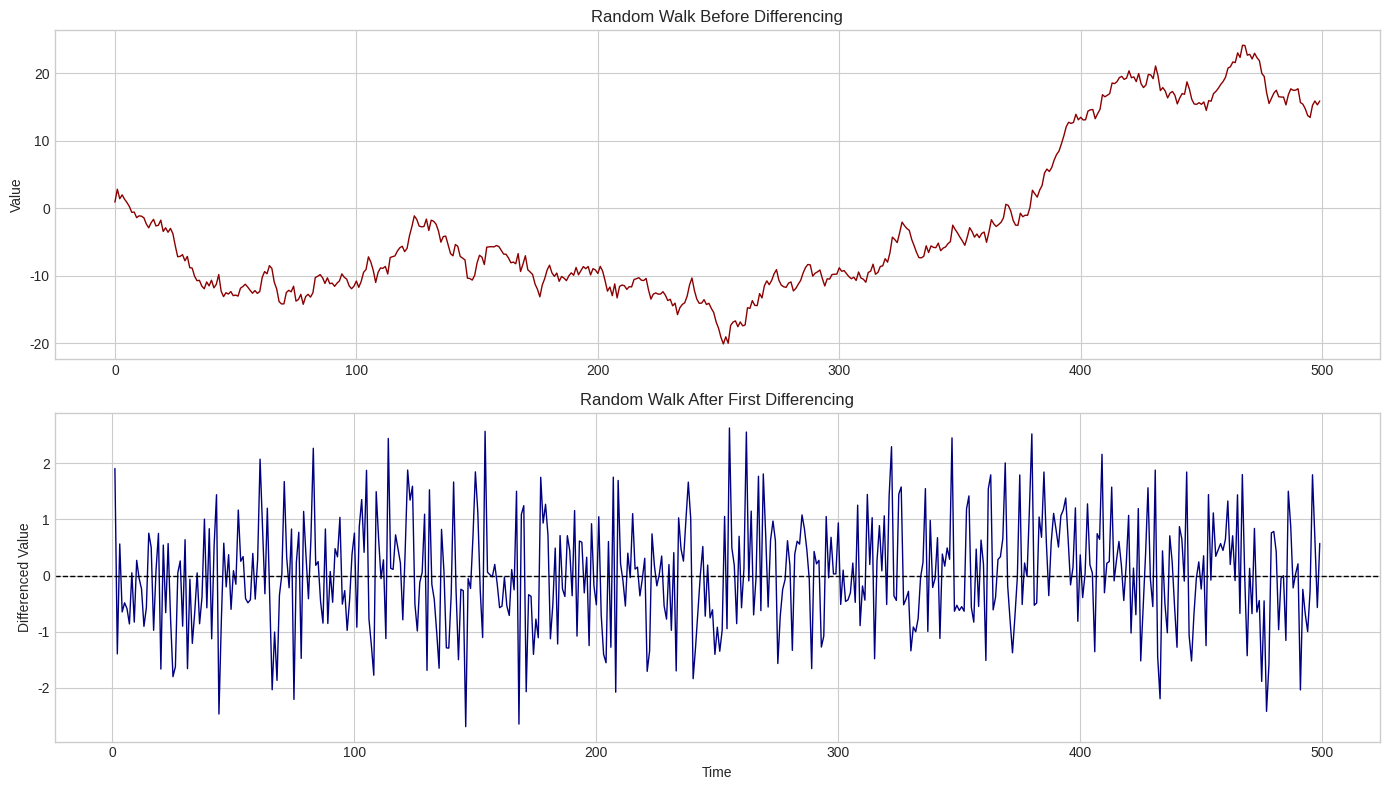

In [16]:
# ============================================
# 16. 차분 전후 비교 플롯
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(rw_series, color="darkred", linewidth=1)
axes[0].set_title("Random Walk Before Differencing")
axes[0].set_ylabel("Value")

axes[1].plot(rw_diff, color="navy", linewidth=1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Random Walk After First Differencing")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Differenced Value")

plt.tight_layout()
plt.show()


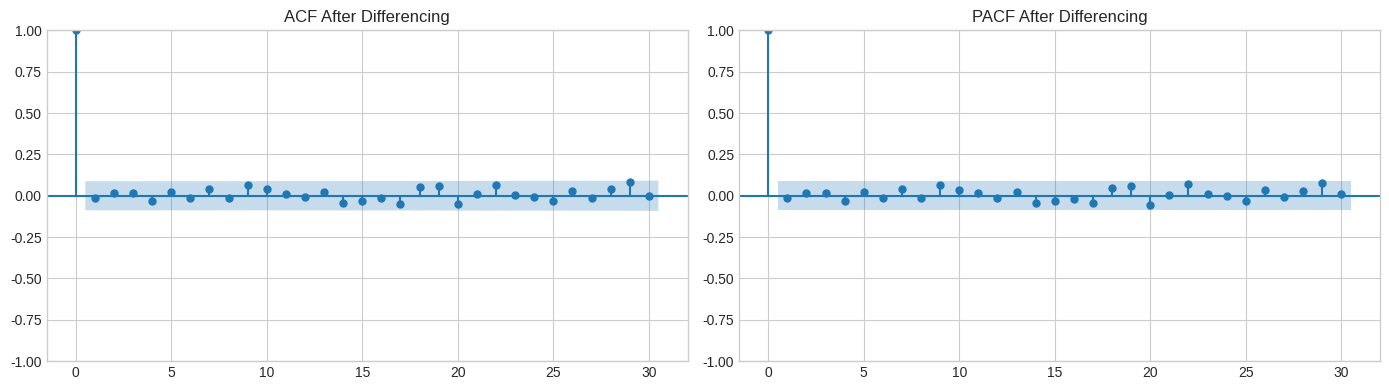

In [17]:
# ============================================
# 17. 차분 후 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(rw_diff, lags=30, ax=axes[0])
plot_pacf(rw_diff, lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF After Differencing")
axes[1].set_title("PACF After Differencing")

plt.tight_layout()
plt.show()


In [18]:
# ============================================
# 18. 차분 후 정상성 검정
# ============================================

stationarity_report(rw_diff, "Differenced Random Walk")


===== Differenced Random Walk =====
ADF Statistic : -22.6202
ADF p-value   : 0.0
KPSS Statistic: 0.4328
KPSS p-value  : 0.063
----------------------------------------


## 9. 실제 금융 데이터로 확인하기
시뮬레이션뿐 아니라 실제 데이터에서도 비슷한 현상이 나타납니다.  
주가 수준(price level)은 종종 비정상성을 보이고, 수익률(return)은 상대적으로 더 안정적인 구조를 보이는 경우가 많습니다.

이번에는 **애플(AAPL)** 의 실제 주가를 이용해 비교해 보겠습니다.


In [19]:
# ============================================
# 19. 실제 금융 데이터 다운로드
# ============================================

ticker = "AAPL"
start_date = "2020-01-01"
end_date = "2024-12-31"

price_df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

price_df["Log_Return"] = np.log(price_df["Close"] / price_df["Close"].shift(1))

print(f"Ticker: {ticker}")
print(f"Shape: {price_df.shape}")
display(price_df.head())


Ticker: AAPL
Shape: (1257, 7)


Price,Adj Close,Close,High,Low,Open,Volume,Log_Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,,
2020-01-02,72.400497,75.087502,75.150002,73.797501,74.059998,135480400,NaN
2020-01-03,71.696640,74.357498,75.144997,74.125000,74.287498,146322800,-0.009770
2020-01-06,72.267937,74.949997,74.989998,73.187500,73.447502,118387200,0.007937
2020-01-07,71.928055,74.597504,75.224998,74.370003,74.959999,108872000,-0.004714
2020-01-08,73.085114,75.797501,76.110001,74.290001,74.290001,132079200,0.015958


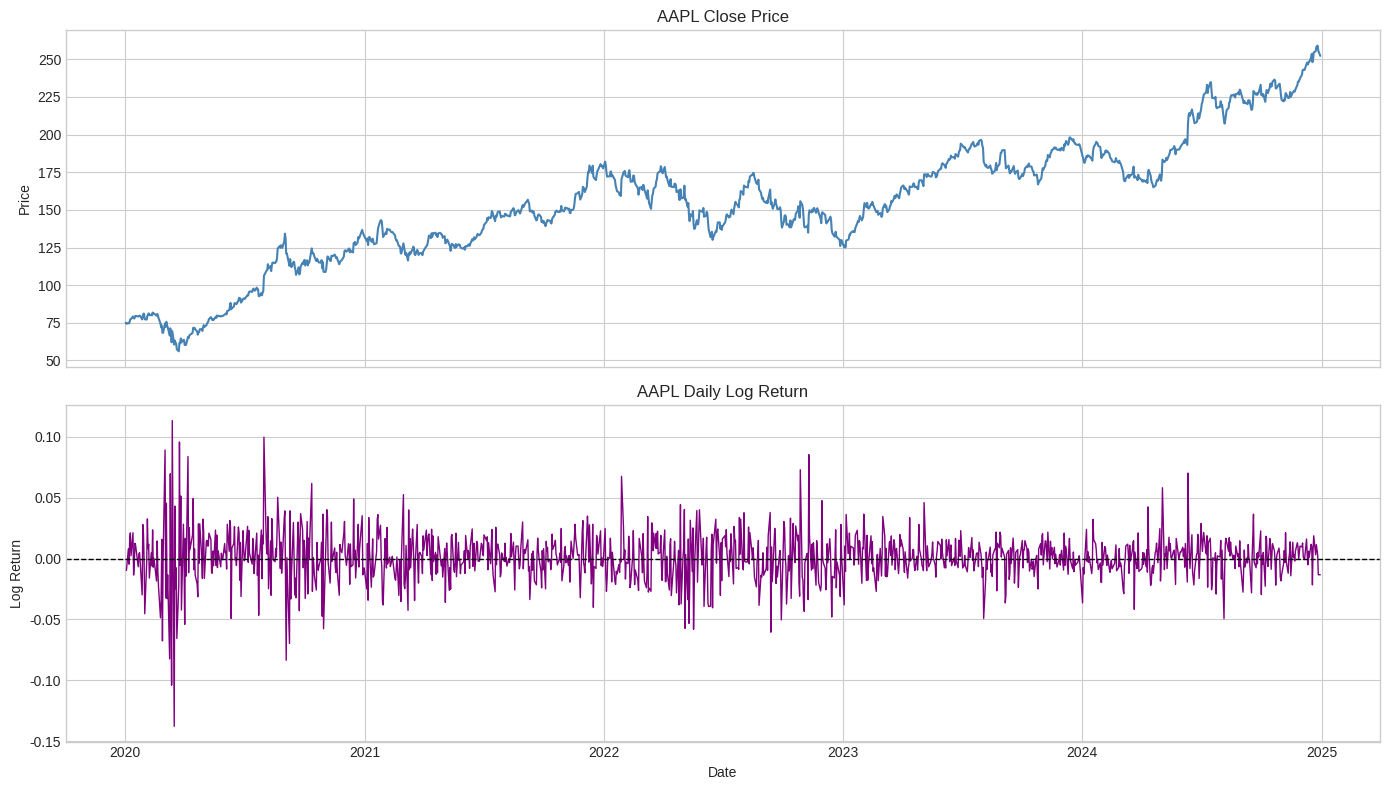

In [20]:
# ============================================
# 20. 가격 수준과 로그 수익률 비교 플롯
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(price_df.index, price_df["Close"], color="steelblue", linewidth=1.5)
axes[0].set_title("AAPL Close Price")
axes[0].set_ylabel("Price")

axes[1].plot(price_df.index, price_df["Log_Return"], color="purple", linewidth=1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("AAPL Daily Log Return")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Log Return")

plt.tight_layout()
plt.show()


## 10. 실제 데이터의 ACF 비교
가격 수준과 수익률은 ACF에서도 큰 차이를 보입니다.

- 가격 수준: 높은 자기상관이 오래 유지될 수 있음
- 수익률: 상대적으로 빠르게 0 근처로 감소하는 경우가 많음


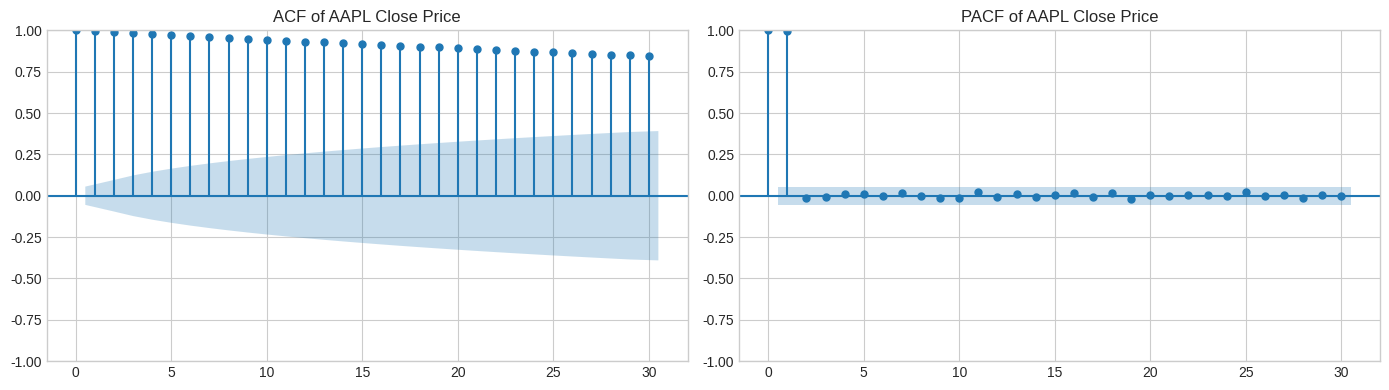

In [21]:
# ============================================
# 21. 가격 수준의 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(price_df["Close"].dropna(), lags=30, ax=axes[0])
plot_pacf(price_df["Close"].dropna(), lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of AAPL Close Price")
axes[1].set_title("PACF of AAPL Close Price")

plt.tight_layout()
plt.show()


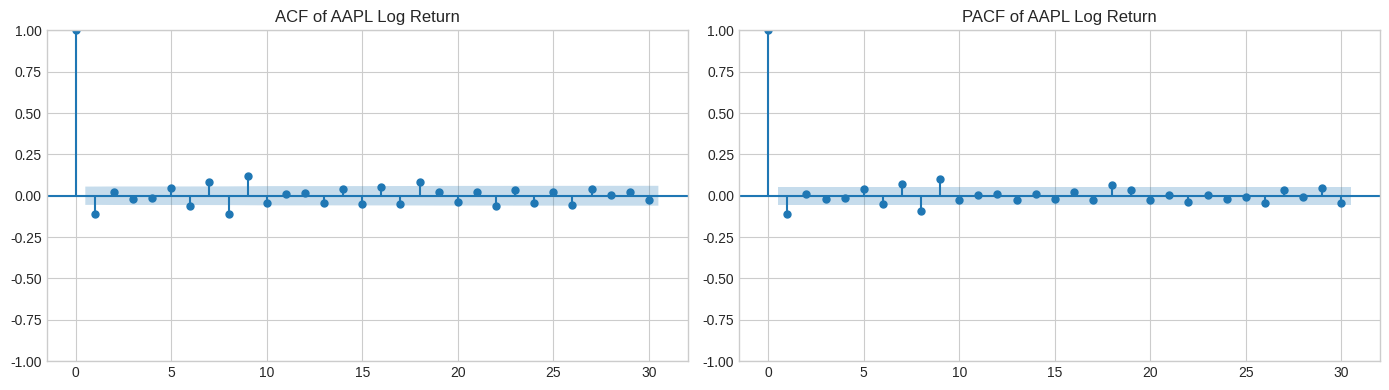

In [22]:
# ============================================
# 22. 로그 수익률의 ACF / PACF
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(price_df["Log_Return"].dropna(), lags=30, ax=axes[0])
plot_pacf(price_df["Log_Return"].dropna(), lags=30, ax=axes[1], method="ywm")

axes[0].set_title("ACF of AAPL Log Return")
axes[1].set_title("PACF of AAPL Log Return")

plt.tight_layout()
plt.show()


In [24]:
# ============================================
# 23. 실제 데이터의 정상성 검정
# ============================================

stationarity_report(price_df["Close"].dropna().squeeze(), "AAPL Close Price")
stationarity_report(price_df["Log_Return"].dropna().squeeze(), "AAPL Log Return")

===== AAPL Close Price =====
ADF Statistic : -0.7258
ADF p-value   : 0.84
KPSS Statistic: 4.9032
KPSS p-value  : 0.01
----------------------------------------
===== AAPL Log Return =====
ADF Statistic : -11.2834
ADF p-value   : 0.0
KPSS Statistic: 0.0774
KPSS p-value  : 0.1
----------------------------------------


/tmp/ipykernel_355/1772362636.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_355/1772362636.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, regression="c", nlags="auto")


## 11. 차분과 수익률의 관계 다시 생각하기
금융 데이터에서는 가격 수준을 1차 차분한 값과 수익률이 매우 가까운 해석을 가질 때가 많습니다.

- 차분: 절대 변화량
- 수익률: 상대 변화율
- 로그 수익률: 연속 복리 관점의 변화율

즉, 비정상적 수준 데이터를 변화량 중심으로 바꾸는 사고가 시계열 분석의 핵심입니다.


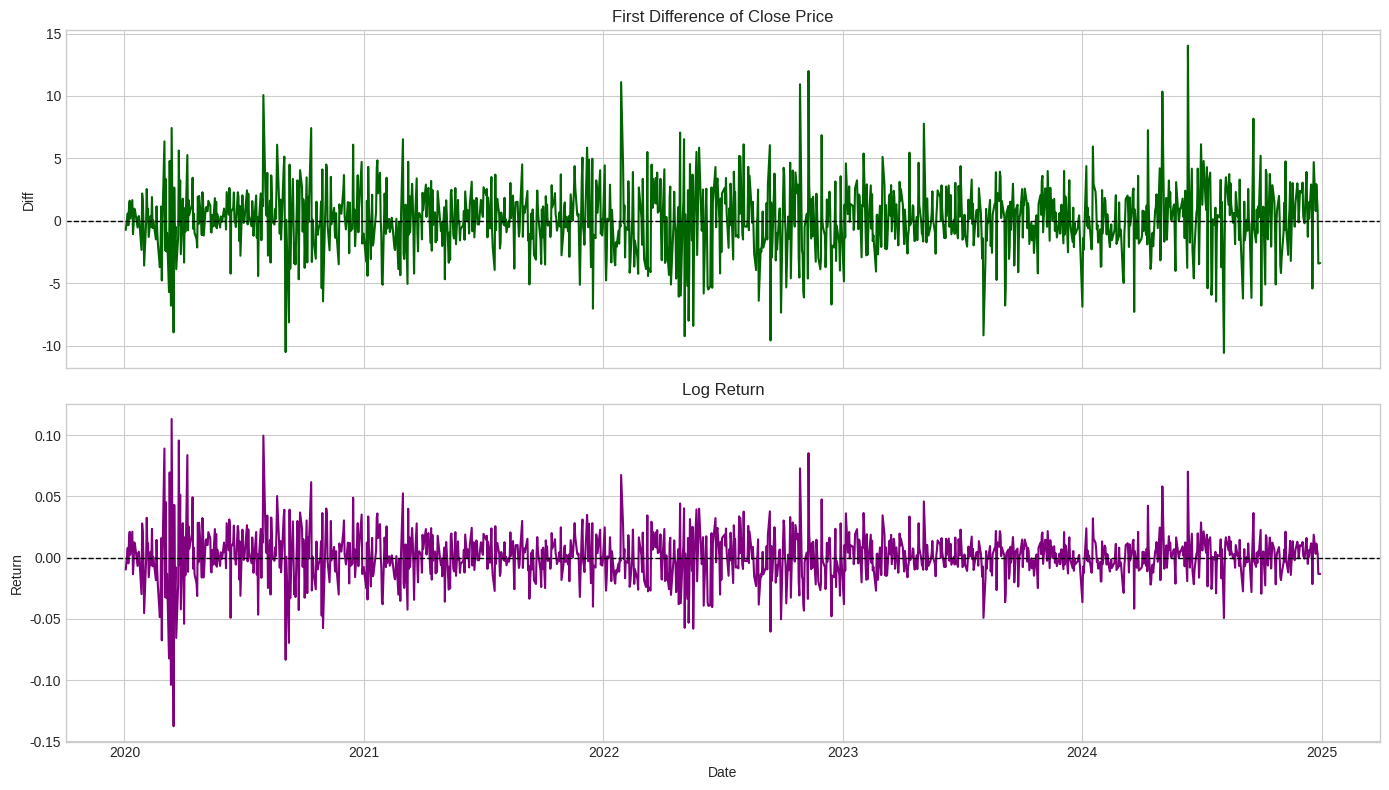

In [25]:
# ============================================
# 24. 가격 차분과 로그 수익률 비교
# ============================================

price_df["Diff_Close"] = price_df["Close"].diff()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(price_df.index, price_df["Diff_Close"], label="First Difference of Close", color="darkgreen")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("First Difference of Close Price")
axes[0].set_ylabel("Diff")

axes[1].plot(price_df.index, price_df["Log_Return"], label="Log Return", color="purple")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Log Return")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Return")

plt.tight_layout()
plt.show()


## 12. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 백색잡음은 정상 시계열의 가장 단순한 기준점이다.
- 랜덤워크는 충격을 누적하므로 비정상성을 보이는 대표적 과정이다.
- ACF가 천천히 감소하면 비정상성 가능성을 의심할 수 있다.
- ADF와 KPSS는 서로 보완적으로 정상성을 점검하는 도구이다.
- 차분은 비정상 시계열을 더 안정적인 형태로 바꾸는 핵심 방법이다.
- 실제 금융 데이터에서도 가격 수준보다 수익률이 더 안정적으로 보이는 경우가 많다.


## 13. 연습문제 (Exercises)

1. 백색잡음 대신 평균이 0이 아닌 정규분포를 생성하여 그래프와 정상성 검정을 비교해 보시오.

2. 랜덤워크에 드리프트(drift)를 추가한 경우 그래프가 어떻게 달라지는지 관찰하시오.

3. 애플(AAPL) 대신 테슬라(TSLA) 또는 마이크로소프트(MSFT) 데이터를 사용하여 가격 수준과 수익률의 ACF를 비교하시오.

4. 랜덤워크를 2차 차분했을 때 어떤 문제가 생길 수 있는지 그래프와 함께 설명해 보시오.

5. ADF와 KPSS의 귀무가설 방향이 왜 서로 반대인지 자신의 언어로 정리해 보시오.
